# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [5]:
from pathlib import Path
import os, shutil, zipfile, random, sys, subprocess, inspect
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

try:
    from google.colab import files
except Exception:
    files = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.2


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [6]:
KAGGLE_JSON_SOURCE = Path.home() / ".kaggle" / "kaggle.json"
local_candidates = [Path("kaggle.json"), Path.cwd() / "kaggle.json", KAGGLE_JSON_SOURCE]

found = None
for c in local_candidates:
    if c.exists():
        found = c
        break
if found is None:
    raise FileNotFoundError("kaggle.json tidak ditemukan.")

kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(parents=True, exist_ok=True)
target = kaggle_dir / "kaggle.json"
if found.resolve() != target.resolve():
    shutil.copy2(found, target)
os.chmod(target, 0o600)
os.environ["KAGGLE_CONFIG_DIR"] = str(kaggle_dir)


In [7]:
DATASET = "fathurrahmanalfarizy/sampah-daur-ulang"
ZIP_PATH = Path("sampah-daur-ulang.zip")
extract_dir = Path("sampah-daur-ulang").expanduser()

def ensure_kaggle_installed():
    try:
        import kaggle
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])

ensure_kaggle_installed()

kaggle_cli = Path(sys.executable).with_name("kaggle")
if not kaggle_cli.exists():
    kaggle_cli = Path(shutil.which("kaggle") or "kaggle")

subprocess.check_call([str(kaggle_cli), "datasets", "download", "-d", DATASET, "-p", ".", "--force"])

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Download gagal: {ZIP_PATH} tidak ditemukan.")

extract_dir.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(extract_dir)
print(f"Ekstraksi selesai ke: {extract_dir}")

EXTRACT_DIR = extract_dir.resolve()

# Tampilkan isi folder (ringkas)
print("\nIsi folder dataset (max 20 item):")
for i, p in enumerate(sorted(extract_dir.rglob("*"))):
    rel = p.relative_to(extract_dir).as_posix()
    print(("  " + rel + "/") if p.is_dir() else ("  " + rel))
    if i >= 19:
        break

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
IMG_EXTS = {".jpg", ".jpeg", ".png"}

Dataset URL: https://www.kaggle.com/datasets/fathurrahmanalfarizy/sampah-daur-ulang
License(s): unknown


100%|██████████| 98.5M/98.5M [01:17<00:00, 1.33MB/s]



Ekstraksi selesai ke: sampah-daur-ulang

Isi folder dataset (max 20 item):
  DATASETS/
  DATASETS/Kaca/
  DATASETS/Kaca/R_3850.jpg
  DATASETS/Kaca/R_3851.jpg
  DATASETS/Kaca/R_3852.jpg
  DATASETS/Kaca/R_3853.jpg
  DATASETS/Kaca/R_3854.jpg
  DATASETS/Kaca/R_3855.jpg
  DATASETS/Kaca/R_3856.jpg
  DATASETS/Kaca/R_3857.jpg
  DATASETS/Kaca/R_3858.jpg
  DATASETS/Kaca/R_3859.jpg
  DATASETS/Kaca/R_3860.jpg
  DATASETS/Kaca/R_3861.jpg
  DATASETS/Kaca/R_3862.jpg
  DATASETS/Kaca/R_3863.jpg
  DATASETS/Kaca/R_3864.jpg
  DATASETS/Kaca/R_3865.jpg
  DATASETS/Kaca/R_3866.jpg
  DATASETS/Kaca/R_3867.jpg


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Jumlah kelas: 6
Nama kelas: ['Kaca', 'Kardus', 'Kertas', 'Logam', 'Plastik', 'Residu']

Total gambar: 7014

Distribusi per kelas:
  Kaca: 1110 gambar
  Kardus: 624 gambar
  Kertas: 1807 gambar
  Logam: 1210 gambar
  Plastik: 1257 gambar
  Residu: 1006 gambar


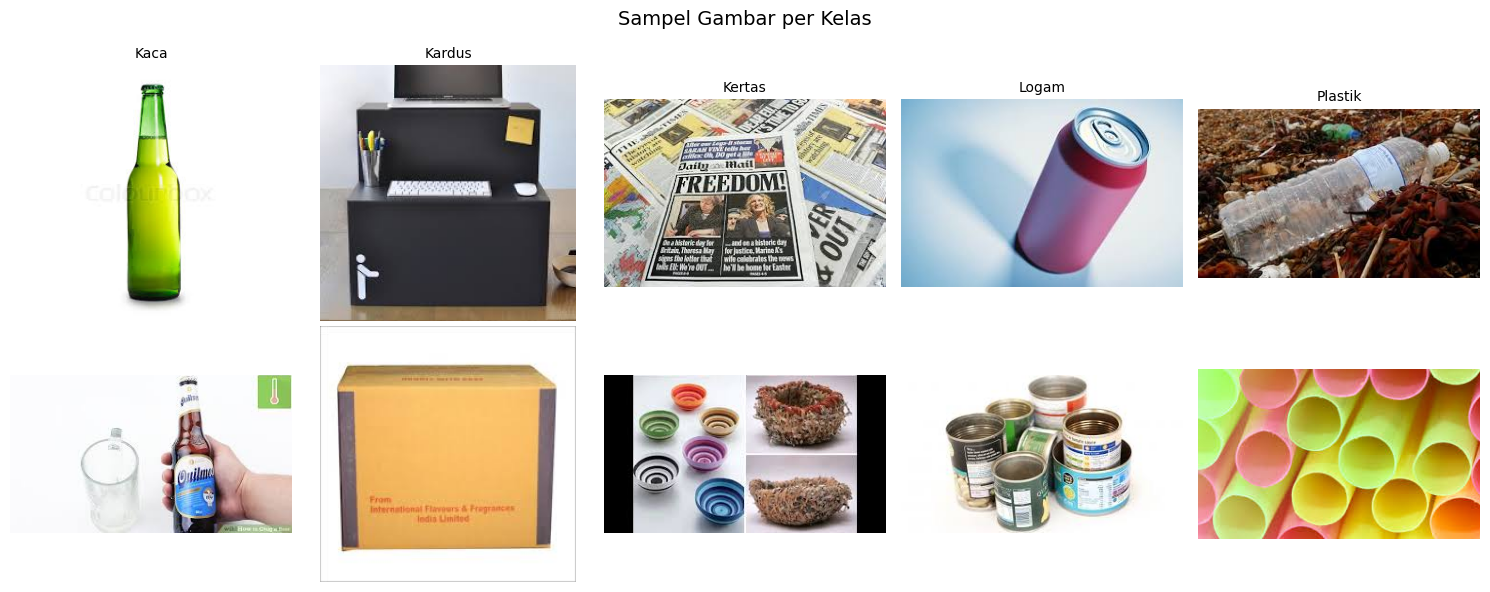


Ukuran gambar (sampel 200):
  Width  - min: 95, max: 2888, mean: 302
  Height - min: 91, max: 1814, mean: 255


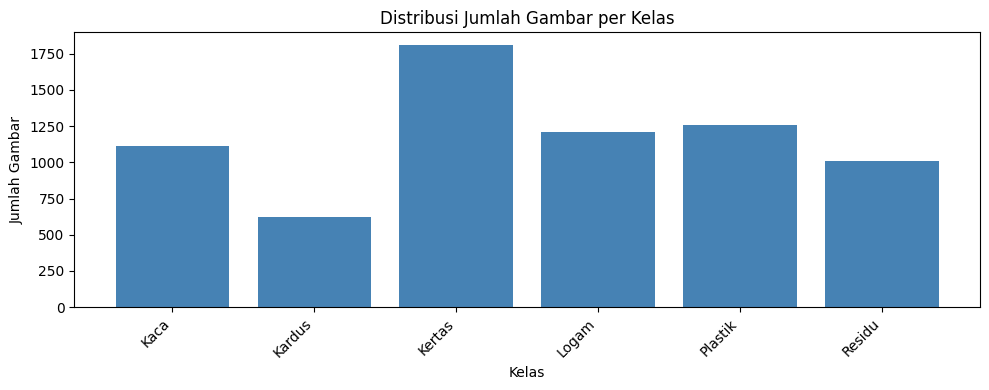

In [8]:
def has_images(path):
    return any(p.is_file() and p.suffix.lower() in IMG_EXTS for p in path.iterdir())

def is_class_root(path):
    subdirs = [d for d in path.iterdir() if d.is_dir()]
    return len(subdirs) >= 2 and sum(1 for d in subdirs if has_images(d)) >= 2

def find_named_dir(root, names):
    for name in names:
        for p in root.rglob(name):
            if p.is_dir():
                return p
    return None

def find_class_root(root):
    for p in root.rglob("*"):
        if p.is_dir() and is_class_root(p):
            return p
    return None

def list_images(base_dir, class_names):
    paths, labels = [], []
    for idx, cls in enumerate(class_names):
        d = Path(base_dir) / cls
        if not d.exists():
            continue
        for p in d.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                paths.append(str(p))
                labels.append(idx)
    return np.array(paths), np.array(labels)

# === Deteksi struktur dataset ===
dataset_root = Path(EXTRACT_DIR)
train_dir = find_named_dir(dataset_root, ["train", "training", "Train", "Training"])
val_dir = find_named_dir(dataset_root, ["val", "valid", "validation", "Val", "Valid", "Validation"])
test_dir = find_named_dir(dataset_root, ["test", "testing", "Test", "Testing"])

class_root = train_dir if train_dir else find_class_root(dataset_root)
if class_root is None:
    raise RuntimeError("Class folders tidak ditemukan.")

class_names = sorted([d.name for d in class_root.iterdir() if d.is_dir()])
NUM_CLASSES = len(class_names)
print(f"Jumlah kelas: {NUM_CLASSES}")
print(f"Nama kelas: {class_names}")

# === Hitung distribusi per kelas ===
base_paths, base_labels = list_images(class_root, class_names)
print(f"\nTotal gambar: {len(base_paths)}")

from collections import Counter
dist = Counter(base_labels)
print("\nDistribusi per kelas:")
for idx, cls in enumerate(class_names):
    print(f"  {cls}: {dist.get(idx, 0)} gambar")

# === Visualisasi sampel gambar per kelas ===
fig, axes = plt.subplots(2, min(NUM_CLASSES, 5), figsize=(15, 6))
if NUM_CLASSES < 5:
    axes = axes if NUM_CLASSES > 1 else [[axes[0]], [axes[1]]]
for idx, cls in enumerate(class_names[:5]):
    cls_imgs = [p for p, l in zip(base_paths, base_labels) if l == idx]
    if cls_imgs:
        img = Image.open(random.choice(cls_imgs)).convert("RGB")
        axes[0][idx].imshow(img)
        axes[0][idx].set_title(cls, fontsize=10)
        axes[0][idx].axis("off")
        # Show second sample
        img2 = Image.open(random.choice(cls_imgs)).convert("RGB")
        axes[1][idx].imshow(img2)
        axes[1][idx].axis("off")
plt.suptitle("Sampel Gambar per Kelas", fontsize=14)
plt.tight_layout()
plt.show()

# === Distribusi ukuran gambar ===
sample_sizes = []
for p in random.sample(list(base_paths), min(200, len(base_paths))):
    try:
        img = Image.open(p)
        sample_sizes.append(img.size)
    except Exception:
        pass

widths = [s[0] for s in sample_sizes]
heights = [s[1] for s in sample_sizes]
print(f"\nUkuran gambar (sampel {len(sample_sizes)}):")
print(f"  Width  - min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"  Height - min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

# === Bar chart distribusi kelas ===
plt.figure(figsize=(10, 4))
counts = [dist.get(i, 0) for i in range(NUM_CLASSES)]
plt.bar(class_names, counts, color="steelblue")
plt.title("Distribusi Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [9]:
idx_arr = np.arange(len(base_paths))
np.random.shuffle(idx_arr)
base_paths = base_paths[idx_arr]
base_labels = base_labels[idx_arr]

n_total = len(base_paths)
n_train = int(n_total * TRAIN_SPLIT)
n_val = int(n_total * VAL_SPLIT)

train_paths = base_paths[:n_train]
train_labels = base_labels[:n_train]
val_paths = base_paths[n_train:n_train + n_val]
val_labels = base_labels[n_train:n_train + n_val]
test_paths = base_paths[n_train + n_val:]
test_labels = base_labels[n_train + n_val:]

# Override jika ada folder terpisah
if val_dir is not None:
    val_paths, val_labels = list_images(val_dir, class_names)
if test_dir is not None:
    test_paths, test_labels = list_images(test_dir, class_names)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

# === Decode & Resize Image ===
def decode_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    return img, label

# === Build tf.data Pipeline ===
def build_ds(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(min(len(paths), 1000), seed=SEED)
    ds = ds.map(decode_img, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_ds(train_paths, train_labels, shuffle=True)
val_ds = build_ds(val_paths, val_labels, shuffle=False)
test_ds = build_ds(test_paths, test_labels, shuffle=False)

print("\nDataset pipeline siap:")
print(f"  class_root : {class_root}")
print(f"  train_dir  : {train_dir}")
print(f"  val_dir    : {val_dir}")
print(f"  test_dir   : {test_dir}")
print(f"  Classes    : {class_names}")
print(f"  IMG_SIZE   : {IMG_SIZE}")
print(f"  BATCH_SIZE : {BATCH_SIZE}")

# === Verifikasi batch pertama ===
for images, labels in train_ds.take(1):
    print(f"\nBatch shape : {images.shape}")
    print(f"Labels shape: {labels.shape}")
    print(f"Pixel range : [{images.numpy().min():.1f}, {images.numpy().max():.1f}]")

# === Data Augmentation Layer ===
def make_data_augmentation():
    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.15),
        tf.keras.layers.RandomZoom(0.15),
        tf.keras.layers.RandomContrast(0.2),
    ], name="data_augmentation")

Train: 4909 | Val: 1052 | Test: 1053

Dataset pipeline siap:
  class_root : /home/brayone-xv/Documents/My File/CODE/pijak-by-dicoding/SML_System_Muhammad Rahman/1-Preprocessing/sampah-daur-ulang/DATASETS
  train_dir  : None
  val_dir    : None
  test_dir   : None
  Classes    : ['Kaca', 'Kardus', 'Kertas', 'Logam', 'Plastik', 'Residu']
  IMG_SIZE   : (224, 224)
  BATCH_SIZE : 32

Batch shape : (32, 224, 224, 3)
Labels shape: (32,)
Pixel range : [0.0, 255.0]


2026-06-06 23:14:39.690460: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
# def make_cell(cell_type, source, cell_id=None):
#     cell = {"cell_type": cell_type, "metadata": {}}
#     if cell_id:
#         cell["metadata"]["id"] = cell_id
#     if cell_type == "code":
#         cell["source"] = source if isinstance(source, list) else [source]
#         cell["execution_count"] = None
#         cell["outputs"] = []
#     else:
#         cell["source"] = source if isinstance(source, list) else [source]
#     return cell

# def code_to_lines(code_str):
#     """Convert multiline string to notebook source list."""
#     lines = code_str.strip().split("\n")
#     result = []
#     for i, line in enumerate(lines):
#         if i < len(lines) - 1:
#             result.append(line + "\n")
#         else:
#             result.append(line)
#     return result

# nb = {
#     "nbformat": 4,
#     "nbformat_minor": 0,
#     "metadata": {
#         "colab": {"provenance": [], "gpuType": "T4"},
#         "kernelspec": {"name": "python3", "display_name": "Python 3"},
#         "language_info": {"name": "python"},
#         "accelerator": "GPU"
#     },
#     "cells": [
#         # 1. Perkenalan Dataset
#         make_cell("markdown", ["# **1. Perkenalan Dataset**\n"], "sec1_title"),
#         make_cell("markdown", [
#             "Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:\n",
#             "\n",
#             "1. **Sumber Dataset**:  \n",
#             "   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.\n",
#             "\n",
#             "**Dataset yang digunakan**: [Sampah Daur Ulang](https://www.kaggle.com/datasets/fathurrahmanalfarizy/sampah-daur-ulang) dari Kaggle.\n",
#             "Dataset ini berisi gambar sampah yang dikategorikan ke dalam beberapa kelas untuk klasifikasi menggunakan deep learning (image classification).\n",
#         ], "sec1_desc"),

#         # 2. Import Library
#         make_cell("markdown", ["# **2. Import Library**"], "sec2_title"),
#         make_cell("markdown", [
#             "Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning."
#         ], "sec2_desc"),
#         make_cell("code", code_to_lines(IMPORT_CODE), "sec2_code"),

#         # 3. Memuat Dataset
#         make_cell("markdown", ["# **3. Memuat Dataset**"], "sec3_title"),
#         make_cell("markdown", [
#             "Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.\n",
#             "\n",
#             "Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.\n",
#             "\n",
#             "Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan"
#         ], "sec3_desc"),
#         make_cell("code", code_to_lines(LOAD_DATASET_CODE), "sec3_code"),

#         # 4. EDA
#         make_cell("markdown", [
#             "# **4. Exploratory Data Analysis (EDA)**\n",
#             "\n",
#             "Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.\n",
#             "\n",
#             "Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan."
#         ], "sec4_title"),
#         make_cell("code", code_to_lines(EDA_CODE), "sec4_code"),

#         # 5. Data Preprocessing
#         make_cell("markdown", ["# **5. Data Preprocessing**"], "sec5_title"),
#         make_cell("markdown", [
#             "Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.\n",
#             "\n",
#             "Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.\n",
#             "\n",
#             "Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:\n",
#             "1. Menghapus atau Menangani Data Kosong (Missing Values)\n",
#             "2. Menghapus Data Duplikat\n",
#             "3. Normalisasi atau Standarisasi Fitur\n",
#             "4. Deteksi dan Penanganan Outlier\n",
#             "5. Encoding Data Kategorikal\n",
#             "6. Binning (Pengelompokan Data)\n",
#             "\n",
#             "Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur."
#         ], "sec5_desc"),
#         make_cell("code", code_to_lines(PREPROCESSING_CODE), "sec5_code"),
#     ]
# }

# with open(OUT, "w", encoding="utf-8") as f:
#     json.dump(nb, f, indent=1, ensure_ascii=False)

# print(f"Template berhasil ditulis ke: {OUT}")

NameError: name 'IMPORT_CODE' is not defined

### Export Hasil Preprocessing (Kriteria 1)
Menyimpan informasi path gambar dan labelnya ke dalam bentuk `.csv` sebagai bukti hasil preprocessing.

In [ ]:
import pandas as pd
import os

# Membuat direktori output jika belum ada
out_dir = 'sampah-daur-ulang_preprocessing'
os.makedirs(out_dir, exist_ok=True)

# Menyimpan dataset path dan label ke CSV
df = pd.DataFrame({'filepath': paths, 'label': labels})
csv_path = os.path.join(out_dir, 'preprocessing_result.csv')
df.to_csv(csv_path, index=False)

print(f'Hasil preprocessing berhasil disimpan ke: {csv_path}')
df.head()